(-10.0, 10.0)

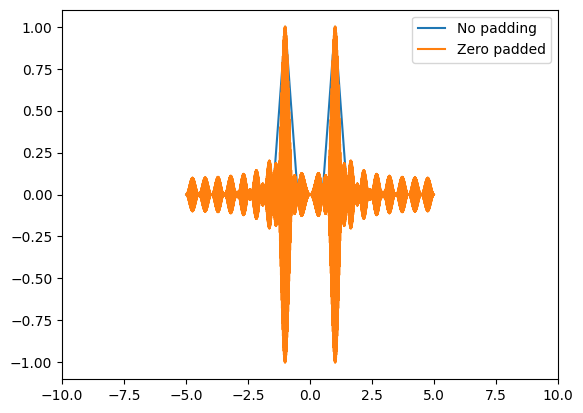

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq, fftshift, ifftshift

dt = 0.1
f = 1
t = np.arange(0,2,dt)
x = np.cos(2*np.pi* f * t)
x_padded = np.concatenate([x, np.zeros(2000)])

X = fftshift(fft(ifftshift(x))) * dt
X_padded = fftshift(fft(ifftshift(x_padded))) * dt

f = fftshift(fftfreq(len(t),dt))
f_padded = fftshift(fftfreq(len(t)+2000,dt))

plt.plot(f, np.real(X), label='No padding')
plt.plot(f_padded, np.real(X_padded), label='Zero padded')
plt.legend()
plt.xlim(-10,10)


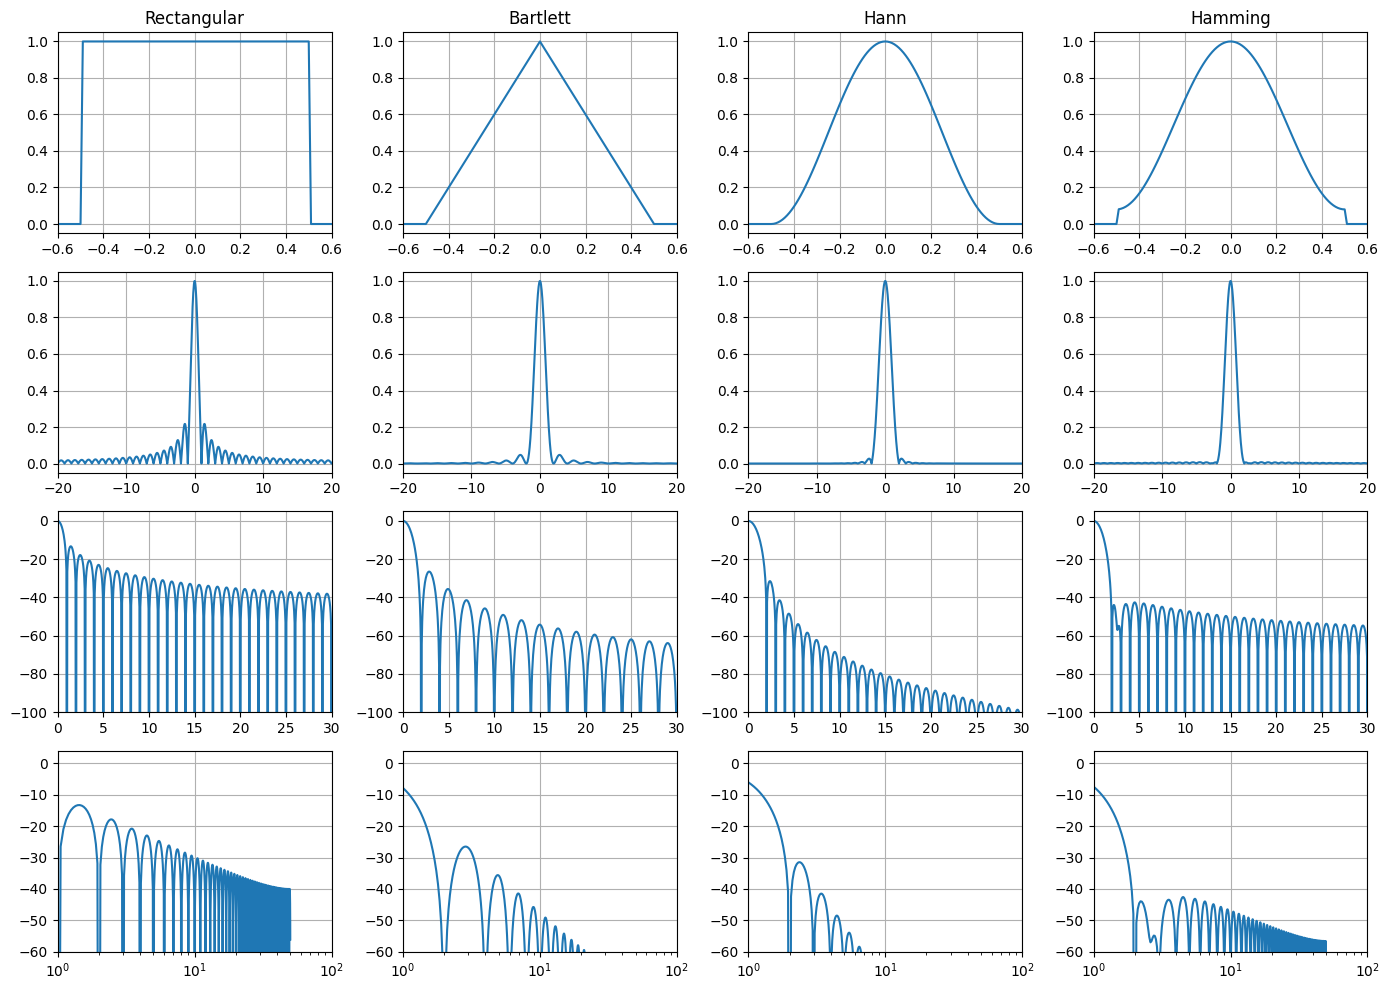

In [21]:
dt = 0.01
t = np.arange(-10, 10, dt)
rect = np.where(np.abs(t) <= 0.5, 1, 0)
bartlett = np.where(np.abs(t) <= 0.5, 1 - 2*np.abs(t), 0)
hann = np.where(np.abs(t) <= 0.5, 0.5 + 0.5*np.cos(2*np.pi*t), 0)
hamming = np.where(np.abs(t) <= 0.5, 0.54 + 0.46*np.cos(2*np.pi*t), 0)

def my_fft(signal, dt):
    return fftshift(fft(ifftshift(signal))) * dt

def to_db(X):
    eps = 1e-12
    return 20*np.log10((np.abs(X) + eps) / np.max(np.abs(X)))

    
freq = fftshift(fftfreq(len(t), dt))

F_rect = my_fft(rect, dt)
F_bartlett = my_fft(bartlett, dt)
F_hann = my_fft(hann, dt)
F_hamming = my_fft(hamming, dt)

windows = {
    "Rectangular": rect,
    "Bartlett": bartlett,
    "Hann": hann,
    "Hamming": hamming
}

fig, axes = plt.subplots(4, 4, figsize=(14, 10))

for col, (name, w) in enumerate(windows.items()):
    W = my_fft(w, dt)
    W_abs = np.abs(W)
    W_db = to_db(W)

    # row 1: time window
    axes[0, col].plot(t, w)
    axes[0, col].set_title(name)
    axes[0, col].set_xlim(-0.6, 0.6)

    # row 2: magnitude, linear
    axes[1, col].plot(freq, W_abs / np.max(W_abs))
    axes[1, col].set_xlim(-20, 20)

    # row 3: magnitude in dB
    axes[2, col].plot(freq, W_db)
    axes[2, col].set_xlim(0, 30)
    axes[2, col].set_ylim(-100, 5)

    # row 4: dB with log frequency axis
    mask = freq > 0
    axes[3, col].semilogx(freq[mask], W_db[mask])
    axes[3, col].set_xlim(1, 100)
    axes[3, col].set_ylim(-60, 4)

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()